# Iris Classification with Logistic Regression

This notebook is the presentation layer for the project. Implementation code is separated into phase-specific Python modules under `phases/`.

## Phase 0: Project Overview

- Problem type: multi-class classification.
- Input: Iris flower geometry features.
- Output: Iris species.
- Main model: Logistic Regression.
- Data split plan: train/test = 80/20.
- Evaluation focus: accuracy, precision, recall, and F1-score.

In [1]:
from IPython.display import Image, display

from phases.phase_01_data_loading import load_iris_dataset
from phases.phase_02_eda import run_eda

## Phase 1: Data Loading & Schema

Source file: `phases/phase_01_data_loading.py`.

Phase 1 loads the Iris dataset, prepares a clean schema, validates required columns and target values, and exports the prepared dataset to `outputs/iris_dataset.csv`.

In [2]:
iris_dataset = load_iris_dataset(export_csv=True)

print(f"Dataset shape: {iris_dataset.dataframe.shape}")
print(f"Feature columns: {iris_dataset.feature_names}")
print(f"Target classes: {iris_dataset.target_names}")

Dataset shape: (150, 6)
Feature columns: ['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm']
Target classes: ['setosa', 'versicolor', 'virginica']


In [3]:
iris_dataset.dataframe.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Phase 1 Notes

- The prepared dataset has 150 samples and 6 columns.
- The 4 feature columns are numeric geometry measurements.
- The target is available as both numeric `target` and readable `species`.
- The prepared dataset is exported for review and reproducibility.

## Phase 2: Exploratory Data Analysis

Source file: `phases/phase_02_eda.py`.

Phase 2 checks data quality, class distribution, feature summaries, class-level feature behavior, and feature correlations. It does not split, scale, train, tune, or evaluate a model.

In [4]:
eda_report = run_eda(iris_dataset, export_artifacts=True)

print(f"Dataset shape: {eda_report.dataset_shape}")
print(f"Duplicate rows: {eda_report.duplicate_count}")
print("Missing values:")
print(eda_report.missing_values)

Dataset shape: (150, 6)
Duplicate rows: 1
Missing values:
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
target             0
species            0
dtype: int64


### Class Distribution

The class distribution shows whether the dataset is balanced across Iris species.

In [5]:
eda_report.class_distribution

,species,count,percentage
0,setosa,50,0.333333
1,versicolor,50,0.333333
2,virginica,50,0.333333


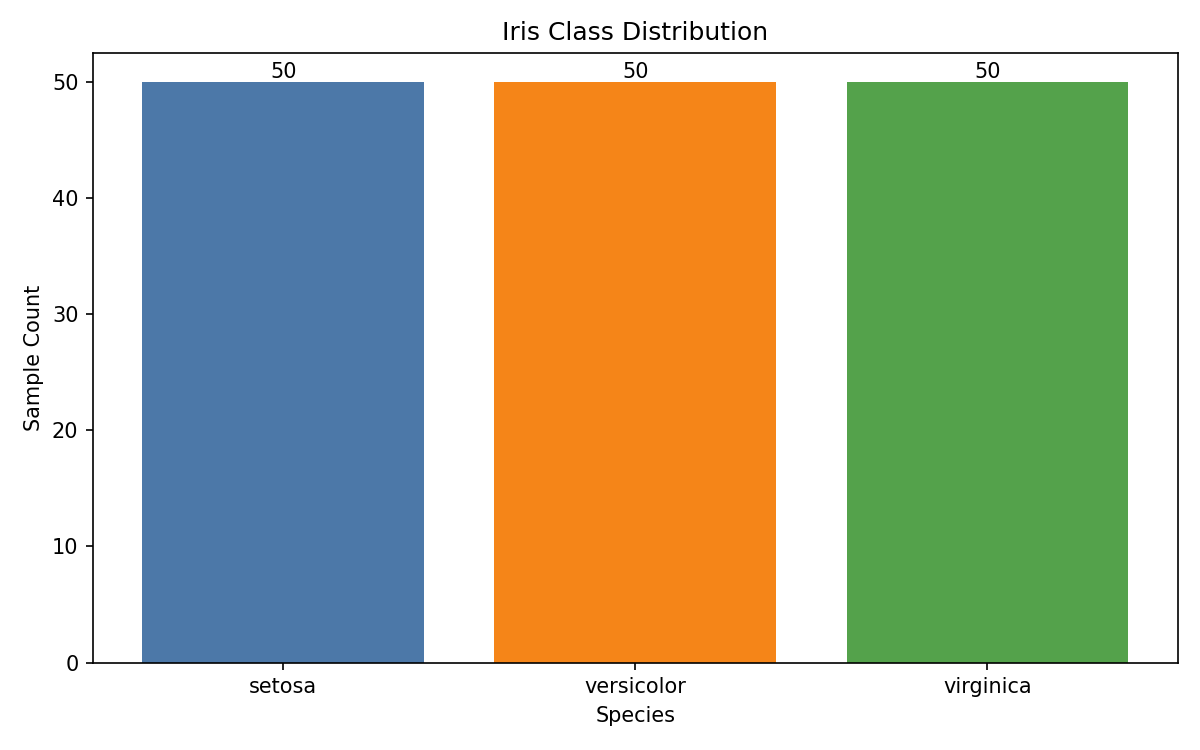

In [6]:
display(Image(filename="outputs/eda/class_distribution.png"))

### Feature Summary

The feature summary provides the central tendency and spread of each numeric input feature.

In [7]:
eda_report.feature_summary

,count,mean,std,min,25%,50%,75%,max
sepal_length_cm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width_cm,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length_cm,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width_cm,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


### Feature Summary by Class

Class-level feature summaries help identify which measurements separate species better.

In [8]:
eda_report.class_feature_summary

sepal_length_cm           sepal_width_cm           petal_length_cm  \
                      mean       std           mean       std            mean   
species                                                                         
setosa               5.006  0.352490          3.428  0.379064           1.462   
versicolor           5.936  0.516171          2.770  0.313798           4.260   
virginica            6.588  0.635880          2.974  0.322497           5.552   

                     petal_width_cm            
                 std           mean       std  
species                                        
setosa      0.173664          0.246  0.105386  
versicolor  0.469911          1.326  0.197753  
virginica   0.551895          2.026  0.274650

### Correlation Matrix

The correlation matrix helps detect highly related input features.

In [9]:
eda_report.correlation_matrix

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000000,-0.117570,0.871754,0.817941
sepal_width_cm,-0.117570,1.000000,-0.428440,-0.366126
petal_length_cm,0.871754,-0.428440,1.000000,0.962865
petal_width_cm,0.817941,-0.366126,0.962865,1.000000


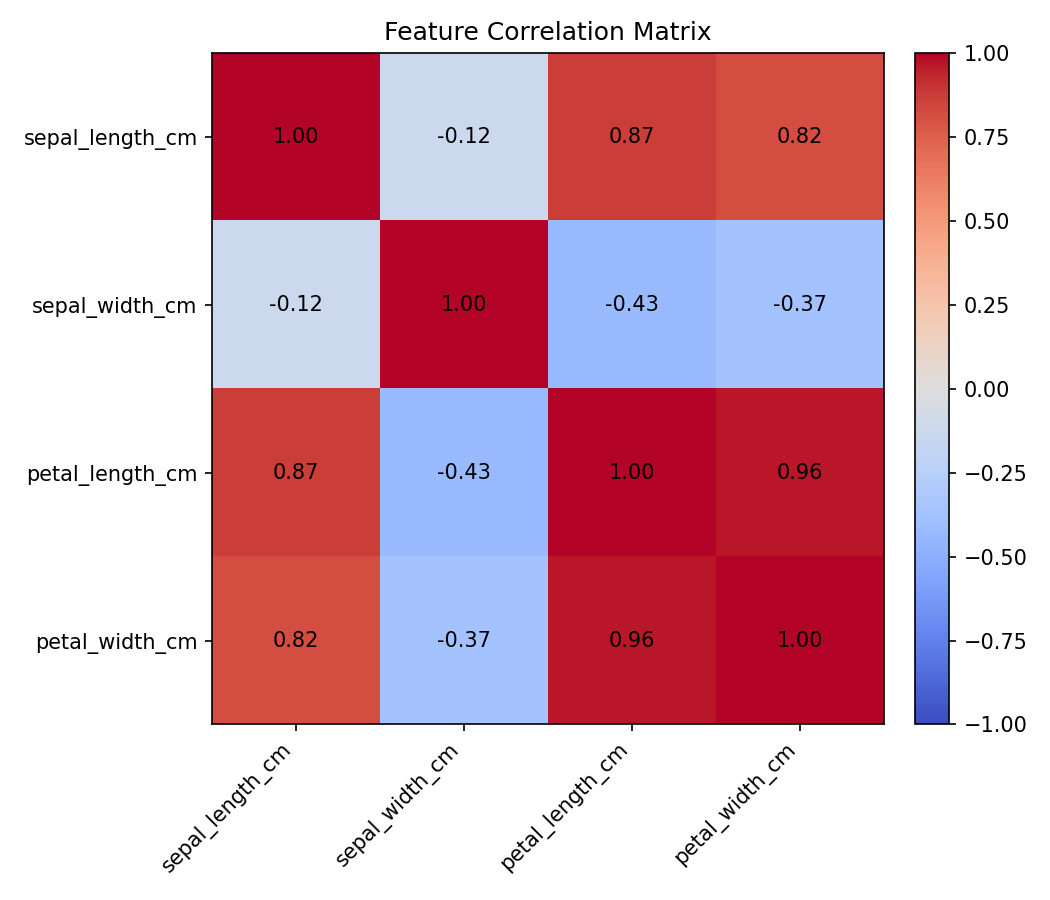

In [10]:
display(Image(filename="outputs/eda/correlation_matrix.png"))

### Phase 2 Notes

- The dataset is balanced: each Iris species has 50 samples.
- There are no missing values.
- One duplicate row is reported and will be handled as a preprocessing decision, not inside EDA.
- `petal_length_cm` and `petal_width_cm` are strongly correlated, so petal features are expected to be important for classification.

## Phase 3: Train/Test Split & Preprocessing

Trong bước này, chúng ta sẽ chia dữ liệu thành tập huấn luyện (train set) và tập kiểm thử (test set) với tỷ lệ 80/20. Đồng thời, chúng ta sẽ áp dụng `StandardScaler` để chuẩn hóa các đặc trưng (features). Việc chuẩn hóa giúp cho thuật toán Logistic Regression hội tụ nhanh và ổn định hơn.

In [11]:
from phases.phase_03_preprocessing import run_preprocessing

preprocessed = run_preprocessing(iris_dataset, export_artifacts=True)
print(f"X_train shape: {preprocessed.X_train_scaled.shape}")
print(f"X_test shape: {preprocessed.X_test_scaled.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)


In [12]:
preprocessed.X_train_scaled.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
8,-1.721568,-0.332101,-1.345722,-1.323276
106,-1.124492,-1.227655,0.414505,0.651763
76,1.144395,-0.555990,0.584850,0.256755
9,-1.124492,0.115676,-1.288941,-1.454945
89,-0.408002,-1.227655,0.130598,0.125086


## Phase 4: Baseline Models

Trước khi huấn luyện mô hình học máy thực thụ, chúng ta thiết lập một Baseline Model (Mô hình cơ sở) sử dụng `DummyClassifier`. Mô hình này luôn dự đoán nhãn xuất hiện nhiều nhất trong tập huấn luyện. Mục đích là để có một điểm chuẩn so sánh xem liệu mô hình Logistic Regression sau này có thực sự học được điều gì từ dữ liệu hay không.

In [13]:
from phases.phase_04_baseline import run_baseline

baseline_report = run_baseline(preprocessed)
print(f"Baseline strategy: {baseline_report.strategy}")
print(f"Baseline accuracy: {baseline_report.accuracy:.4f}")

Baseline strategy: most_frequent
Baseline accuracy: 0.3333


## Phase 5: Model Tuning

Tại đây, chúng ta sử dụng `GridSearchCV` để tìm kiếm siêu tham số tốt nhất (Hyperparameter tuning) cho mô hình `LogisticRegression`. Các tham số được thử nghiệm bao gồm hằng số điều chuẩn `C` và thuật toán tối ưu `solver`.

In [14]:
from phases.phase_05_model_tuning import run_tuning

tuned_model_report = run_tuning(preprocessed, export_artifacts=True)
print(f"Best Parameters: {tuned_model_report.best_params}")
print(f"Best CV Score (Accuracy): {tuned_model_report.best_cv_score:.4f}")

Best Parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Score (Accuracy): 0.9667


## Phase 6: Final Evaluation

Sử dụng mô hình tốt nhất từ Phase 5, chúng ta dự đoán trên tập kiểm thử (test set) và đánh giá chi tiết thông qua các chỉ số như Accuracy, Precision, Recall và F1-score. Ma trận nhầm lẫn (Confusion Matrix) cũng được trực quan hóa để xem chi tiết dự đoán cho từng nhãn.

In [15]:
from phases.phase_06_evaluation import run_evaluation

evaluation_report = run_evaluation(preprocessed, tuned_model_report, export_artifacts=True)
print(f"Test Accuracy: {evaluation_report.accuracy:.4f}")
print("\nClassification Report:")
print(evaluation_report.classification_report)

Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



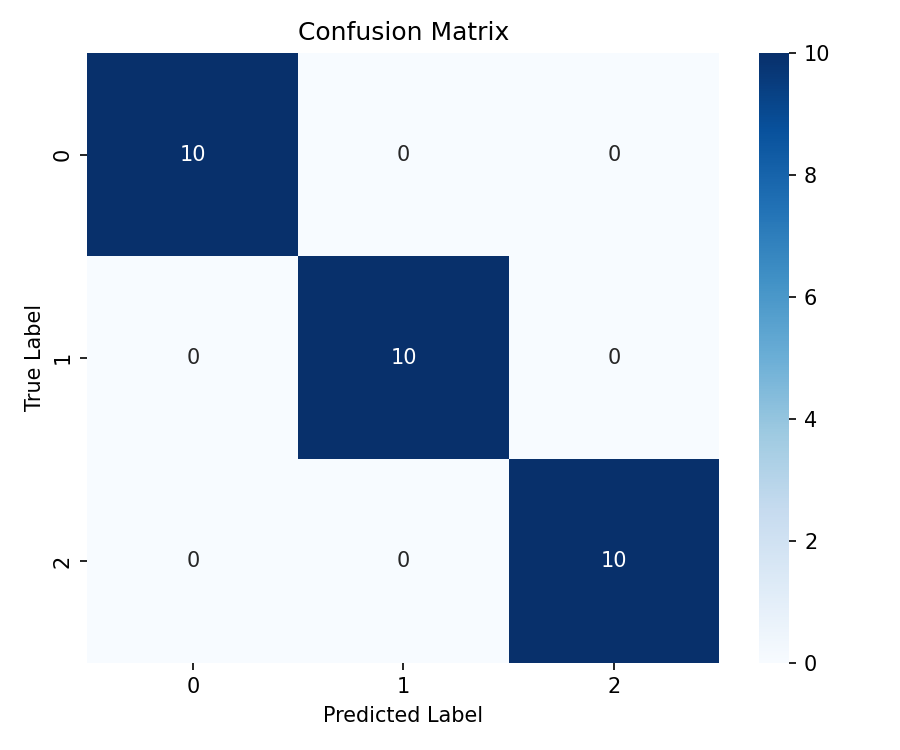

In [16]:
display(Image(filename='outputs/evaluation/confusion_matrix.png'))

## Phase 7: Prediction Analysis

Phân tích các mẫu bị phân loại sai (Misclassified samples). Việc xem xét các dự đoán sai giúp ta hiểu rõ hơn điểm yếu của mô hình và ranh giới phân định giữa các lớp khó phân biệt (thường là Versicolor và Virginica).

In [17]:
from phases.phase_07_prediction_analysis import run_prediction_analysis

prediction_report = run_prediction_analysis(preprocessed, tuned_model_report, export_artifacts=True)
print(f"Misclassified samples count: {len(prediction_report.misclassified_df)}")
prediction_report.misclassified_df

Misclassified samples count: 0


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,true_label,predicted_label,prob_0,prob_1,prob_2,is_correct


## Phase 8: Model Interpretation

Cuối cùng, chúng ta trích xuất các trọng số (coefficients) của mô hình Logistic Regression để hiểu mức độ ảnh hưởng của từng đặc trưng lên quyết định phân loại cho từng nhãn loài hoa.

In [18]:
from phases.phase_08_interpretation import run_interpretation

interpretation_report = run_interpretation(preprocessed, tuned_model_report, export_artifacts=True)
interpretation_report.coefficients_df

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
class_0,-1.800891,1.721987,-3.310499,-3.184500
class_1,1.133151,-0.289376,-1.145210,-1.442879
class_2,0.667740,-1.432610,4.455709,4.627378


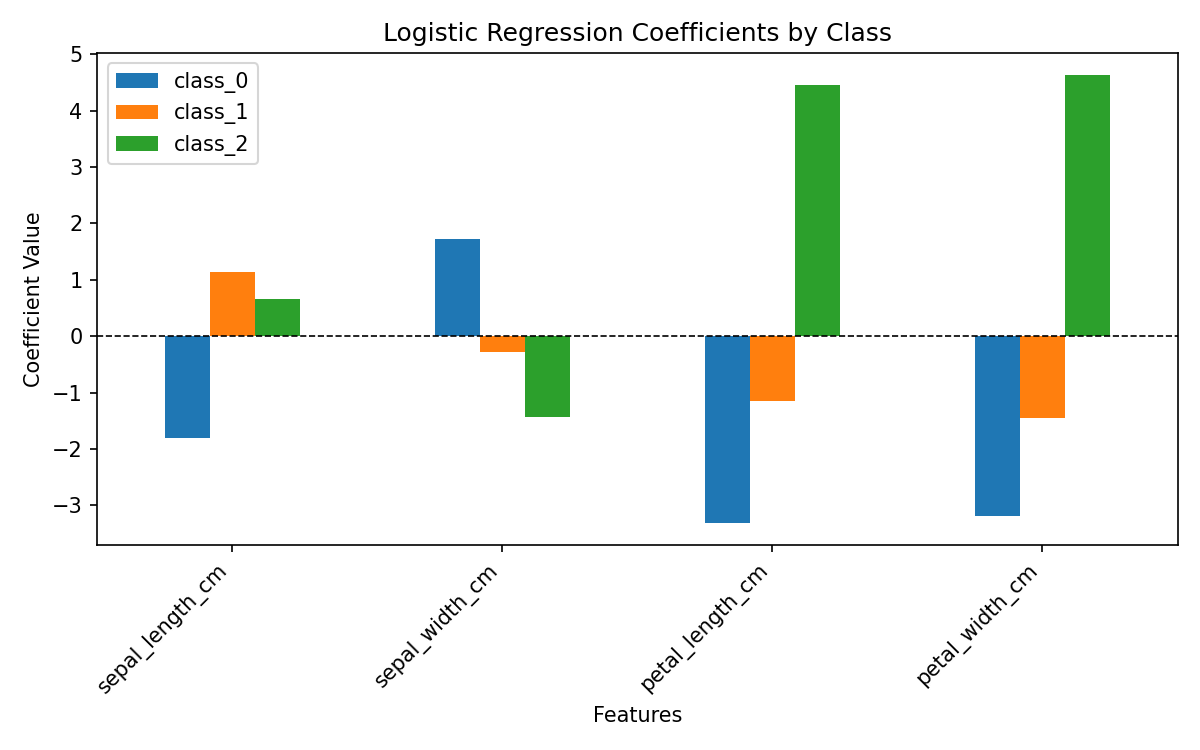

In [19]:
display(Image(filename='outputs/interpretation/coefficients_plot.png'))

## Phase 9: Conclusion

Qua quá trình phân tích và huấn luyện, mô hình Logistic Regression đã chứng minh khả năng phân loại rất tốt đối với tập dữ liệu Iris. Việc chuẩn hóa dữ liệu, sử dụng baseline model và thực hiện tinh chỉnh tham số (hyperparameter tuning) đã giúp tìm ra mô hình tối ưu nhất một cách rõ ràng và khoa học. Các trường hợp phân loại sai (nếu có) phản ánh tính chất thực tế của ranh giới giữa một số nhãn trong bộ dữ liệu.